In [1]:
!pip -q install librosa

import os, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import librosa
from google.colab import drive
drive.mount('/content/drive')

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Mounted at /content/drive
Device: cpu


In [3]:
import os
import re
import copy
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple

import librosa
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models as tv_models
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [4]:
@dataclass
class Config:
    base_dir: str = "/content/drive/MyDrive/Colab Notebooks/dataset/Audio"
    batch_size: int = 32
    num_workers: int = 0
    learning_rate: float = 1e-4
    epochs: int = 10   # changed from 5 -> 10
    duration: float = 10.0
    segment_length: float = 0.25
    sr: int = 44100
    n_mfcc: int = 40
    n_fft: int = 2048
    hop_length: int = 512

In [6]:
# ------------------------
# Helpers
# ------------------------
def numerical_sort(value: str):
    parts = re.split(r"(\d+)", value)
    parts[1::2] = map(int, parts[1::2])
    return parts


def validate_split_dir(split_dir: str, split_name: str) -> None:
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"{split_name} split not found: {split_dir}")

    for category in ["Drone", "Background"]:
        category_dir = os.path.join(split_dir, category)
        if not os.path.isdir(category_dir):
            raise FileNotFoundError(
                f"Missing category folder '{category}' in {split_name}: {category_dir}"
            )

In [7]:
class DroneAudioSegmentDataset(Dataset):
    """
    Audio-only dataset from wav folders.
    Each 10-second wav file is split into 0.25-second segments.
    For each segment, a normalized MFCC tensor with shape (1, 40, 40) is returned.
    Labels:
        Drone = 1
        Background = 0
    """

    def __init__(
        self,
        audio_root_split: str,
        duration: float = 10.0,
        segment_length: float = 0.25,
        sr: int = 44100,
        n_mfcc: int = 40,
        n_fft: int = 2048,
        hop_length: int = 512,
    ):
        self.audio_root_split = audio_root_split
        self.duration = duration
        self.segment_length = segment_length
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.num_segments = int(self.duration / self.segment_length)
        self.samples = self._load_samples()

        if len(self.samples) == 0:
            raise ValueError(f"No audio samples were found in: {audio_root_split}")

    def _load_samples(self) -> List[Dict]:
        samples: List[Dict] = []

        for category in ["Drone", "Background"]:
            label = 1 if category == "Drone" else 0
            category_path = os.path.join(self.audio_root_split, category)

            if not os.path.isdir(category_path):
                continue

            scenario_dirs = sorted(
                [
                    d for d in os.listdir(category_path)
                    if os.path.isdir(os.path.join(category_path, d))
                ],
                key=numerical_sort,
            )

            for scenario in scenario_dirs:
                scenario_path = os.path.join(category_path, scenario)

                audio_files = sorted(
                    [f for f in os.listdir(scenario_path) if f.lower().endswith(".wav")],
                    key=numerical_sort,
                )

                for audio_file in audio_files:
                    audio_path = os.path.join(scenario_path, audio_file)

                    for seg_idx in range(self.num_segments):
                        samples.append(
                            {
                                "audio_path": audio_path,
                                "start": seg_idx * self.segment_length,
                                "label": label,
                            }
                        )

        return samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sample = self.samples[idx]

        y, _ = librosa.load(
            sample["audio_path"],
            sr=self.sr,
            mono=True,
            offset=sample["start"],
            duration=self.segment_length,
        )

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=self.sr,
            n_mfcc=self.n_mfcc,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
        )

        mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-8)

        # force shape to (40, 40)
        mfcc = mfcc[:, : self.n_mfcc]
        pad_width = max(0, self.n_mfcc - mfcc.shape[1])
        if pad_width > 0:
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")

        x = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)   # [1, 40, 40]
        label = torch.tensor(sample["label"], dtype=torch.long)
        return x, label

In [8]:
class GlobalPooling2D(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), x.size(1), -1)
        return torch.mean(x, dim=2)


class AudioVGG19TRIDENT(nn.Module):
    """
    Keep the same VGG19 backbone, but output 2 classes
    to match RF-style evaluation.
    """

    def __init__(self):
        super().__init__()
        vgg_features = list(tv_models.vgg19(weights=None).features)
        vgg_features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
        self.features = nn.Sequential(*vgg_features)
        self.global_pool = GlobalPooling2D()
        self.bn = nn.BatchNorm1d(512)
        self.fc = nn.Linear(512, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.global_pool(x)
        x = self.bn(x)
        x = self.fc(x)
        return x

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in tqdm(loader, desc="TRAIN", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.detach().cpu())
        all_labels.append(y.detach().cpu())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    epoch_acc = accuracy_score(y_true, y_pred)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, phase_name="VAL"):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=phase_name, leave=False):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            running_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.detach().cpu())
            all_labels.append(y.detach().cpu())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    epoch_acc = accuracy_score(y_true, y_pred)

    return epoch_loss, epoch_acc, y_true, y_pred


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device, phase_name="VAL"
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"TRAIN -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f}\n"
            f"VAL   -> Loss: {val_loss:.4f} | Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            print(f"Saved best model at epoch {best_epoch}")

    model.load_state_dict(best_state)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

    return model, history

In [10]:
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_fn(y_true, y_pred, title="Confusion Matrix"):
    class_names = ["Background", "Drone"]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def plot_per_class_metrics_group(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["Background", "Drone"]

    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    accuracy = [accuracy_score(y_true, y_pred)] * len(class_names)

    x = np.arange(len(class_names))
    width = 0.2

    plt.figure(figsize=(8, 5))
    plt.bar(x - 1.5 * width, precision, width, label="Precision")
    plt.bar(x - 0.5 * width, recall, width, label="Recall")
    plt.bar(x + 0.5 * width, f1, width, label="F1-score")
    plt.bar(x + 1.5 * width, accuracy, width, label="Accuracy")

    plt.xticks(x, class_names)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"Per-Class Metrics ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_classification_report_fn(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["Background", "Drone"]
    print(f"\n===== {dataset_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [11]:
cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dir = os.path.join(cfg.base_dir, "Train")
val_dir = os.path.join(cfg.base_dir, "Validation")
test_dir = os.path.join(cfg.base_dir, "Test")

validate_split_dir(train_dir, "Train")
validate_split_dir(val_dir, "Validation")
validate_split_dir(test_dir, "Test")

train_ds = DroneAudioSegmentDataset(
    train_dir,
    duration=cfg.duration,
    segment_length=cfg.segment_length,
    sr=cfg.sr,
    n_mfcc=cfg.n_mfcc,
    n_fft=cfg.n_fft,
    hop_length=cfg.hop_length,
)

val_ds = DroneAudioSegmentDataset(
    val_dir,
    duration=cfg.duration,
    segment_length=cfg.segment_length,
    sr=cfg.sr,
    n_mfcc=cfg.n_mfcc,
    n_fft=cfg.n_fft,
    hop_length=cfg.hop_length,
)

test_ds = DroneAudioSegmentDataset(
    test_dir,
    duration=cfg.duration,
    segment_length=cfg.segment_length,
    sr=cfg.sr,
    n_mfcc=cfg.n_mfcc,
    n_fft=cfg.n_fft,
    hop_length=cfg.hop_length,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))

x_batch, y_batch = next(iter(train_loader))
print("Batch X shape:", x_batch.shape)
print("Batch y shape:", y_batch.shape)

Using device: cpu
Train samples: 8480
Validation samples: 1280
Test samples: 1320
Batch X shape: torch.Size([32, 1, 40, 40])
Batch y shape: torch.Size([32])


In [12]:
model = AudioVGG19TRIDENT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)

print(model)

AudioVGG19TRIDENT(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), strid

In [13]:
trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=cfg.epochs,
)


Epoch 1/10


TRAIN -> Loss: 0.3356 | Acc: 0.8689
VAL   -> Loss: 5.6384 | Acc: 0.3750
Saved best model at epoch 1

Epoch 2/10


TRAIN -> Loss: 0.2639 | Acc: 0.9006
VAL   -> Loss: 2.0902 | Acc: 0.4320
Saved best model at epoch 2

Epoch 3/10


TRAIN -> Loss: 0.2247 | Acc: 0.9179
VAL   -> Loss: 0.4990 | Acc: 0.8289
Saved best model at epoch 3

Epoch 4/10


TRAIN -> Loss: 0.1980 | Acc: 0.9277
VAL   -> Loss: 8.3690 | Acc: 0.6250

Epoch 5/10


...

TRAIN -> Loss: 0.1647 | Acc: 0.9358
VAL   -> Loss: 1.6272 | Acc: 0.6258

Epoch 7/10


TRAIN -> Loss: 0.1557 | Acc: 0.9421
VAL   -> Loss: 8.6659 | Acc: 0.3750

Epoch 8/10


TRAIN -> Loss: 0.1529 | Acc: 0.9403
VAL   -> Loss: 1.6133 | Acc: 0.5477

Epoch 9/10


TRAIN -> Loss: 0.1477 | Acc: 0.9442
VAL   -> Loss: 0.1728 | Acc: 0.9344
Saved best model at epoch 9

Epoch 10/10


TRAIN -> Loss: 0.1345 | Acc: 0.9504
VAL   -> Loss: 1.7874 | Acc: 0.6312

Best Validation Accuracy: 0.9344 at epoch 9


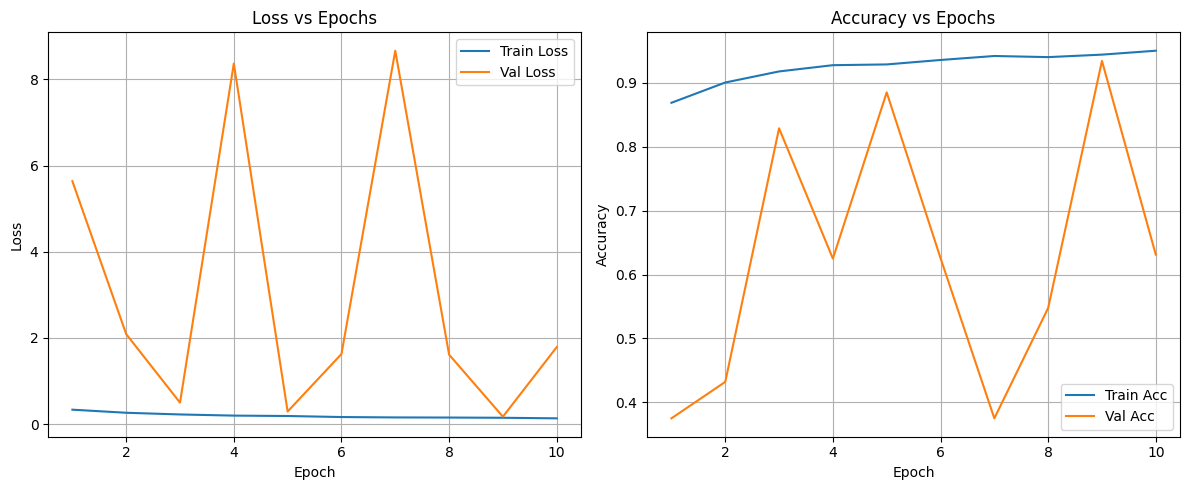

In [14]:
plot_training_history(history)

Train Loss: 0.0944
Train Accuracy: 0.9671


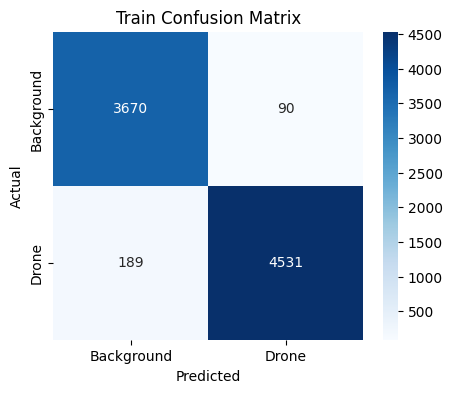

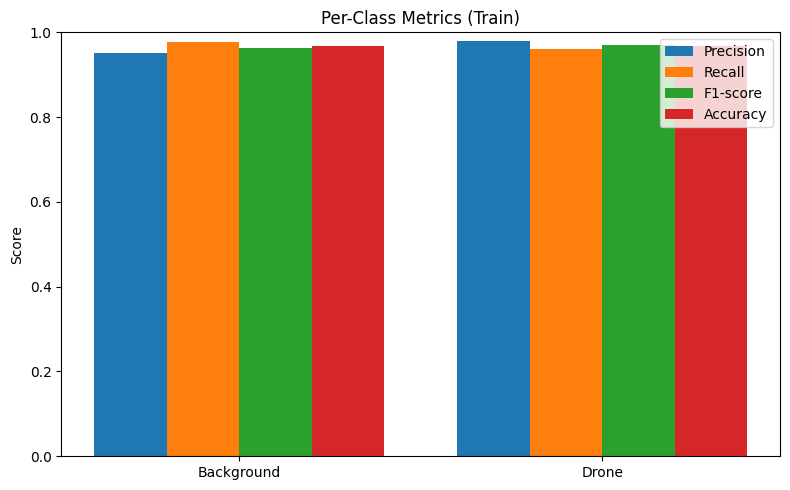


===== Train Classification Report =====
              precision    recall  f1-score   support

  Background     0.9510    0.9761    0.9634      3760
       Drone     0.9805    0.9600    0.9701      4720

    accuracy                         0.9671      8480
   macro avg     0.9658    0.9680    0.9668      8480
weighted avg     0.9674    0.9671    0.9671      8480



In [15]:
train_loss, train_acc, y_true_train, y_pred_train = evaluate(
    trained_model, train_loader, criterion, device, phase_name="TRAIN-EVAL"
)

print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")

plot_confusion_matrix_fn(y_true_train, y_pred_train, title="Train Confusion Matrix")
plot_per_class_metrics_group(y_true_train, y_pred_train, dataset_name="Train")
print_classification_report_fn(y_true_train, y_pred_train, dataset_name="Train")

Validation Loss: 0.1728
Validation Accuracy: 0.9344


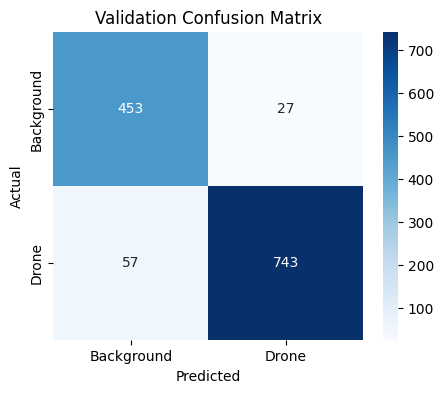

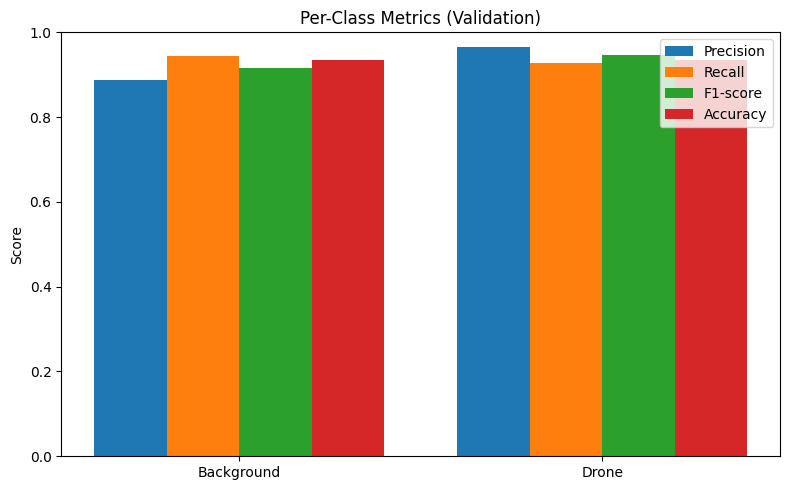


===== Validation Classification Report =====
              precision    recall  f1-score   support

  Background     0.8882    0.9437    0.9152       480
       Drone     0.9649    0.9287    0.9465       800

    accuracy                         0.9344      1280
   macro avg     0.9266    0.9363    0.9308      1280
weighted avg     0.9362    0.9344    0.9347      1280



In [16]:
val_loss, val_acc, y_true_val, y_pred_val = evaluate(
    trained_model, val_loader, criterion, device, phase_name="VAL-EVAL"
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

plot_confusion_matrix_fn(y_true_val, y_pred_val, title="Validation Confusion Matrix")
plot_per_class_metrics_group(y_true_val, y_pred_val, dataset_name="Validation")
print_classification_report_fn(y_true_val, y_pred_val, dataset_name="Validation")

Test Loss: 0.1622
Test Accuracy: 0.9273


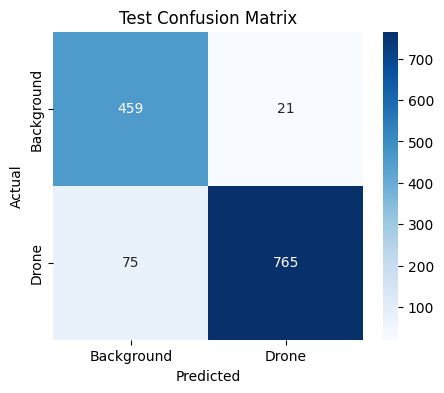

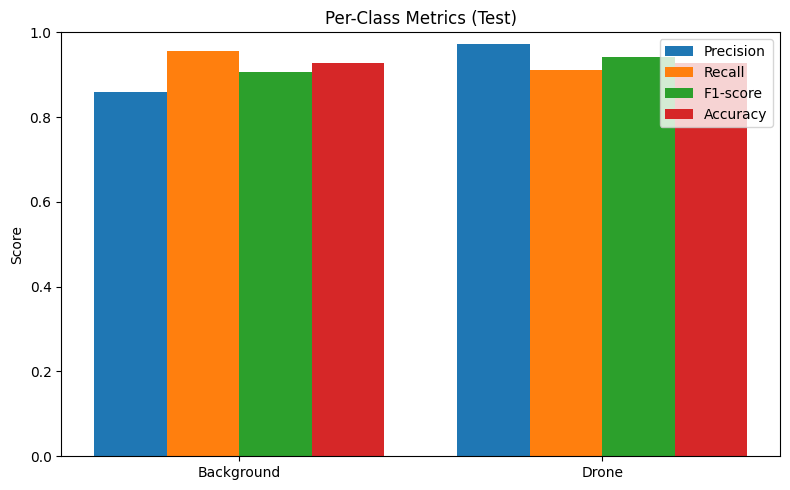


===== Test Classification Report =====
              precision    recall  f1-score   support

  Background     0.8596    0.9563    0.9053       480
       Drone     0.9733    0.9107    0.9410       840

    accuracy                         0.9273      1320
   macro avg     0.9164    0.9335    0.9231      1320
weighted avg     0.9319    0.9273    0.9280      1320



In [17]:
test_loss, test_acc, y_true_test, y_pred_test = evaluate(
    trained_model, test_loader, criterion, device, phase_name="TEST"
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

plot_confusion_matrix_fn(y_true_test, y_pred_test, title="Test Confusion Matrix")
plot_per_class_metrics_group(y_true_test, y_pred_test, dataset_name="Test")
print_classification_report_fn(y_true_test, y_pred_test, dataset_name="Test")